# 01 - Compreensão dos Dados | Case Olist

Pergunta norteadora: Como a eficiência logística da Olist afeta o crescimento e a
sustentabilidade da receita, e onde estão as maiores oportunidades para acelerar
esse crescimento sem comprometer a experiência do cliente?

Neste notebook vamos:
- Carregar as 9 tabelas do dataset da Olist
- Ver o tamanho de cada uma
- Checar se tem dado faltando (nulo) ou duplicado
- Entender o período coberto pelos pedidos
- Fazer as primeiras contas para as trilhas de Crescimento e de Logística

Antes de rodar, baixe o dataset em
https://www.kaggle.com/datasets/olistbr/brazilian-ecommerce e coloque os 9
arquivos `.csv` dentro da pasta `data/base/`, sem renomear.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

## 1. Carregando os dados

In [2]:
customers = pd.read_csv("../data/base/olist_customers_dataset.csv")
orders = pd.read_csv("../data/base/olist_orders_dataset.csv")
order_items = pd.read_csv("../data/base/olist_order_items_dataset.csv")
order_payments = pd.read_csv("../data/base/olist_order_payments_dataset.csv")
order_reviews = pd.read_csv("../data/base/olist_order_reviews_dataset.csv")
products = pd.read_csv("../data/base/olist_products_dataset.csv")
sellers = pd.read_csv("../data/base/olist_sellers_dataset.csv")
geolocation = pd.read_csv("../data/base/olist_geolocation_dataset.csv")
category_translation = pd.read_csv("../data/base/product_category_name_translation.csv")

print("Todas as tabelas foram carregadas!")

Todas as tabelas foram carregadas!


## 2. Quantas linhas e colunas cada tabela tem

In [3]:
print("customers:", customers.shape)
print("orders:", orders.shape)
print("order_items:", order_items.shape)
print("order_payments:", order_payments.shape)
print("order_reviews:", order_reviews.shape)
print("products:", products.shape)
print("sellers:", sellers.shape)
print("geolocation:", geolocation.shape)
print("category_translation:", category_translation.shape)

customers: (99441, 5)
orders: (99441, 8)
order_items: (112650, 7)
order_payments: (103886, 5)
order_reviews: (99224, 7)
products: (32951, 9)
sellers: (3095, 4)
geolocation: (1000163, 5)
category_translation: (71, 2)


## 3. Olhando as primeiras linhas das tabelas principais

In [4]:
orders.head()

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 00:00:00
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15 00:00:00
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26 00:00:00


In [5]:
order_items.head()

,order_id,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value
0,00010242fe8c5a6d1ba2dd792cb16214,1,4244733e06e7ecb4970a6e2683c13e61,48436dade18ac8b2bce089ec2a041202,2017-09-19 09:45:35,58.90,13.29
1,00018f77f2f0320c557190d7a144bdd3,1,e5f2d52b802189ee658865ca93d83a8f,dd7ddc04e1b6c2c614352b383efe2d36,2017-05-03 11:05:13,239.90,19.93
2,000229ec398224ef6ca0657da4fc703e,1,c777355d18b72b67abbeef9df44fd0fd,5b51032eddd242adc84c38acab88f23d,2018-01-18 14:48:30,199.00,17.87
3,00024acbcdf0a6daa1e931b038114c75,1,7634da152a4610f1595efa32f14722fc,9d7a1d34a5052409006425275ba1c2b4,2018-08-15 10:10:18,12.99,12.79
4,00042b26cf59d7ce69dfabb4e55b4fd9,1,ac6c3623068f30de03045865e4e10089,df560393f3a51e74553ab94004ba5c87,2017-02-13 13:57:51,199.90,18.14


In [6]:
order_reviews.head()

,review_id,order_id,review_score,review_comment_title,review_comment_message,review_creation_date,review_answer_timestamp
0,7bc2406110b926393aa56f80a40eba40,73fc7af87114b39712e6da79b0a377eb,4,NaN,NaN,2018-01-18 00:00:00,2018-01-18 21:46:59
1,80e641a11e56f04c1ad469d5645fdfde,a548910a1c6147796b98fdf73dbeba33,5,NaN,NaN,2018-03-10 00:00:00,2018-03-11 03:05:13
2,228ce5500dc1d8e020d8d1322874b6f0,f9e4b658b201a9f2ecdecbb34bed034b,5,NaN,NaN,2018-02-17 00:00:00,2018-02-18 14:36:24
3,e64fb393e7b32834bb789ff8bb30750e,658677c97b385a9be170737859d3511b,5,NaN,Recebi bem antes do prazo estipulado.,2017-04-21 00:00:00,2017-04-21 22:02:06
4,f7c4243c7fe1938f181bec41a392bdeb,8e6bfb81e283fa7e4f11123a3fb894f1,5,NaN,Parabéns lojas lannister adorei comprar pela I...,2018-03-01 00:00:00,2018-03-02 10:26:53


## 4. Verificando valores nulos (dado faltando)

In [7]:
print(orders.isnull().sum())

order_id                            0
customer_id                         0
order_status                        0
order_purchase_timestamp            0
order_approved_at                 160
order_delivered_carrier_date     1783
order_delivered_customer_date    2965
order_estimated_delivery_date       0
dtype: int64


In [8]:
print(order_reviews.isnull().sum())

review_id                      0
order_id                       0
review_score                   0
review_comment_title       87656
review_comment_message     58247
review_creation_date           0
review_answer_timestamp        0
dtype: int64


In [9]:
print(products.isnull().sum())

product_id                      0
product_category_name         610
product_name_lenght           610
product_description_lenght    610
product_photos_qty            610
product_weight_g                2
product_length_cm               2
product_height_cm               2
product_width_cm                2
dtype: int64


`order_delivered_customer_date` tem valor nulo em alguns pedidos. Vamos ver se isso é um problema ou se é porque o pedido ainda não foi entregue.

In [10]:
pedidos_sem_entrega = orders[orders["order_delivered_customer_date"].isnull()]
print(pedidos_sem_entrega["order_status"].value_counts())

order_status
shipped        1107
canceled        619
unavailable     609
invoiced        314
processing      301
delivered         8
created           5
approved          2
Name: count, dtype: int64


Os pedidos sem data de entrega são os que ainda não foram entregues (cancelados, em transporte, etc). Isso é esperado, não é um erro nos dados.

## 5. Verificando linhas duplicadas

In [11]:
print("customers:", customers.duplicated().sum())
print("orders:", orders.duplicated().sum())
print("order_items:", order_items.duplicated().sum())
print("order_payments:", order_payments.duplicated().sum())
print("order_reviews:", order_reviews.duplicated().sum())
print("products:", products.duplicated().sum())
print("sellers:", sellers.duplicated().sum())
print("geolocation:", geolocation.duplicated().sum())
print("category_translation:", category_translation.duplicated().sum())

customers: 0


orders: 0


order_items: 0


order_payments: 0
order_reviews: 0
products: 0
sellers: 0


geolocation: 261831
category_translation: 0


## 6. Transformando as colunas de data de `orders` em datas de verdade

No CSV, as datas chegam como texto. Precisamos converter para o tipo `datetime` do pandas para poder calcular prazos e fazer gráficos por mês.

In [12]:
orders["order_purchase_timestamp"] = pd.to_datetime(orders["order_purchase_timestamp"])
orders["order_approved_at"] = pd.to_datetime(orders["order_approved_at"])
orders["order_delivered_carrier_date"] = pd.to_datetime(orders["order_delivered_carrier_date"])
orders["order_delivered_customer_date"] = pd.to_datetime(orders["order_delivered_customer_date"])
orders["order_estimated_delivery_date"] = pd.to_datetime(orders["order_estimated_delivery_date"])

## 7. Verificando se as datas fazem sentido

Antes de usar essas datas para calcular prazos, vale conferir se elas seguem uma ordem lógica: a aprovação deveria vir depois da compra, a postagem depois da aprovação, e a entrega depois da postagem.

In [13]:
aprovacao_antes_compra = orders[orders["order_approved_at"] < orders["order_purchase_timestamp"]]
print("Pedidos com aprovação antes da compra:", len(aprovacao_antes_compra))

Pedidos com aprovação antes da compra: 0


In [14]:
postagem_antes_aprovacao = orders[orders["order_delivered_carrier_date"] < orders["order_approved_at"]]
print("Pedidos com postagem antes da aprovação:", len(postagem_antes_aprovacao))

Pedidos com postagem antes da aprovação: 1359


In [15]:
entrega_antes_postagem = orders[orders["order_delivered_customer_date"] < orders["order_delivered_carrier_date"]]
print("Pedidos com entrega antes da postagem:", len(entrega_antes_postagem))

Pedidos com entrega antes da postagem: 23


1.359 pedidos (1,37%) têm a postagem registrada antes da aprovação, e 23 pedidos (0,02%) têm a entrega antes da postagem. São inconsistências pontuais nos timestamps — volume baixo o suficiente para não comprometer as análises agregadas, mas vale lembrar disso se algum cálculo de prazo específico der um resultado negativo estranho.

## 8. Período coberto pelos pedidos

In [16]:
print("Primeiro pedido:", orders["order_purchase_timestamp"].min())
print("Último pedido:", orders["order_purchase_timestamp"].max())

Primeiro pedido: 2016-09-04 21:15:19
Último pedido: 2018-10-17 17:30:18


## 9. Quantos pedidos existem em cada status

In [17]:
print(orders["order_status"].value_counts())

order_status
delivered      96478
shipped         1107
canceled         625
unavailable      609
invoiced         314
processing       301
created            5
approved           2
Name: count, dtype: int64


## 10. Quantidade de pedidos por mês

Isso ajuda a ver se o número de pedidos está crescendo ao longo do tempo (trilha de Crescimento).

In [18]:
orders["ano_mes"] = orders["order_purchase_timestamp"].dt.to_period("M")
pedidos_por_mes = orders.groupby("ano_mes")["order_id"].count()
print(pedidos_por_mes)

ano_mes
2016-09       4
2016-10     324
2016-12       1
2017-01     800
2017-02    1780
2017-03    2682
2017-04    2404
2017-05    3700
2017-06    3245
2017-07    4026
2017-08    4331
2017-09    4285
2017-10    4631
2017-11    7544
2017-12    5673
2018-01    7269
2018-02    6728
2018-03    7211
2018-04    6939
2018-05    6873
2018-06    6167
2018-07    6292
2018-08    6512
2018-09      16
2018-10       4
Freq: M, Name: order_id, dtype: int64


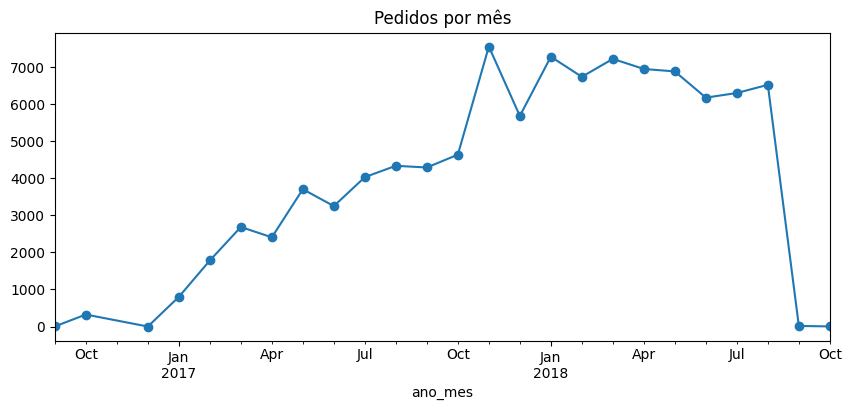

In [19]:
pedidos_por_mes.plot(kind="line", marker="o", figsize=(10, 4), title="Pedidos por mês")
plt.show()

Os meses do início (set/2016 a dez/2016) e do fim (set/2018 e out/2018) têm pouquíssimos pedidos. Isso não é um erro: é só o começo e o fim do período coberto pelo dataset. Ao fazer gráficos de evolução mensal, vale considerar apenas de jan/2017 a ago/2018, para não distorcer a análise.

## 11. Quantidade média de itens por pedido

In [20]:
itens_por_pedido = order_items.groupby("order_id")["order_item_id"].count()
print("Média de itens por pedido:", itens_por_pedido.mean())
print("Pedido com mais itens:", itens_por_pedido.max())

Média de itens por pedido: 1.1417306873695092
Pedido com mais itens: 21


## 12. Clientes únicos x pedidos

`customer_id` muda a cada pedido. `customer_unique_id` identifica o mesmo cliente mesmo que ele compre mais de uma vez.

In [21]:
print("Número de pedidos (customer_id):", customers["customer_id"].nunique())
print("Número de clientes únicos (customer_unique_id):", customers["customer_unique_id"].nunique())

Número de pedidos (customer_id): 99441
Número de clientes únicos (customer_unique_id): 96096


## 13. Nota média das avaliações

In [22]:
print("Nota média:", order_reviews["review_score"].mean())
print(order_reviews["review_score"].value_counts().sort_index())

Nota média: 4.08642062404257
review_score
1    11424
2     3151
3     8179
4    19142
5    57328
Name: count, dtype: int64


## 14. O atraso na entrega afeta a nota da avaliação?

Esta é a pergunta que liga as duas trilhas escolhidas pelo grupo: Crescimento e Receita, e Logística e SLA.

In [23]:
entregues = orders[orders["order_status"] == "delivered"].copy()
entregues["atrasado"] = entregues["order_delivered_customer_date"] > entregues["order_estimated_delivery_date"]

print(entregues["atrasado"].value_counts())

atrasado
False    88652
True      7826
Name: count, dtype: int64


In [24]:
avaliacoes_com_atraso = order_reviews.merge(entregues[["order_id", "atrasado"]], on="order_id")
print(avaliacoes_com_atraso.groupby("atrasado")["review_score"].mean())

atrasado
False    4.293737
True     2.566494
Name: review_score, dtype: float64


A nota média cai bastante quando o pedido chega atrasado. Isso é uma associação entre as duas variáveis, não uma prova de causa e efeito — outros fatores podem influenciar os dois lados. Mas é um bom ponto de partida para a análise de Logística.

## 15. Salvando um resumo simples da qualidade dos dados

In [25]:
nomes_tabelas = ["customers", "orders", "order_items", "order_payments", "order_reviews",
                  "products", "sellers", "geolocation", "category_translation"]

tabelas = [customers, orders, order_items, order_payments, order_reviews,
           products, sellers, geolocation, category_translation]

linhas = []
for nome, tabela in zip(nomes_tabelas, tabelas):
    linhas.append({
        "tabela": nome,
        "linhas": tabela.shape[0],
        "colunas": tabela.shape[1],
        "duplicadas": tabela.duplicated().sum(),
    })

resumo = pd.DataFrame(linhas)
print(resumo)

resumo.to_csv("../documentos/data_quality_summary.csv", index=False)
print("Resumo salvo em documentos/data_quality_summary.csv")

                 tabela   linhas  colunas  duplicadas
0             customers    99441        5           0
1                orders    99441        9           0
2           order_items   112650        7           0
3        order_payments   103886        5           0
4         order_reviews    99224        7           0
5              products    32951        9           0
6               sellers     3095        4           0
7           geolocation  1000163        5      261831
8  category_translation       71        2           0
Resumo salvo em documentos/data_quality_summary.csv
